In [1]:
from datasets import load_dataset

train = load_dataset("mispeech/speechocean762", split="train", trust_remote_code=True)
test  = load_dataset("mispeech/speechocean762", split="test",  trust_remote_code=True)

print(len(train), len(test))          # esperamos 2500 y 2500

ex = train[0]
print(ex.keys())
print("texto  :", ex["text"])
print("fluency:", ex["fluency"])
print("audio  :", {k: (v if k != 'array' else f'array len={len(v)}') for k,v in ex['audio'].items()})

/Users/rnorel/.pyenv/versions/3.11.14/envs/fluency-from-alignment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:00<00:00, 13836.54 examples/s]


2500 2500
dict_keys(['accuracy', 'completeness', 'fluency', 'prosodic', 'text', 'total', 'words', 'speaker', 'gender', 'age', 'audio'])
texto  : WE CALL IT BEAR
fluency: 9
audio  : {'path': '000010011.wav', 'array': 'array len=41280', 'sampling_rate': 16000}


# 01 — Explore speechocean762

Goal: load the dataset and understand the prediction target before doing any modeling.

[speechocean762](https://huggingface.co/datasets/mispeech/speechocean762) is an open-source
corpus for pronunciation assessment: 5,000 English utterances from 250 non-native speakers
(adults and children), each scored by 5 experts. We focus on the **fluency** label, which
is defined as speaking *smoothly and without unnecessary pauses* — a target that maps
directly onto pause structure we can extract from the audio.

Here we check three things: (1) that audio ships with the data, (2) the sampling rate,
and (3) how the fluency scores are distributed — which determines how we model.

## Load and inspect one example

We confirm each sample carries the raw audio (not just the text), and check the sampling
rate — this decides whether we'll need to resample before feeding audio to the aligner.

## Target distribution: fluency scores

The fluency label is what we'll predict, so its distribution shapes the whole approach —
whether we treat it as continuous or categorical, and which validation metric is honest.

Matplotlib is building the font cache; this may take a moment.


fluency
1       6
2       4
3      23
4      84
5     153
6     168
7     416
8     776
9     691
10    179
Name: count, dtype: int64


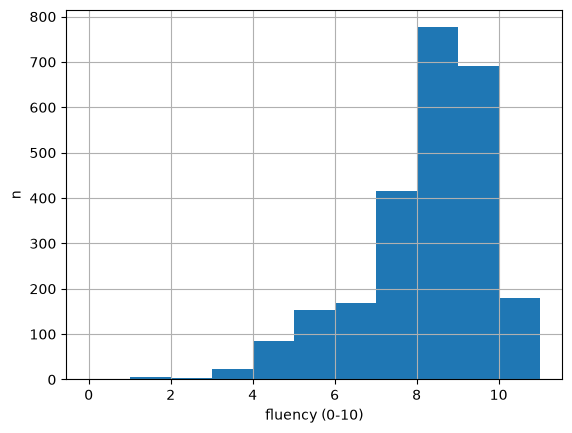

In [2]:
import pandas as pd, matplotlib.pyplot as plt

# Access columns directly (not row-by-row) to avoid decoding audio just to read the labels.
df = pd.DataFrame({"fluency": train["fluency"], "accuracy": train["accuracy"], "total": train["total"]})
print(df["fluency"].value_counts().sort_index())
df["fluency"].hist(bins=range(0,12)); plt.xlabel("fluency (0-10)"); plt.ylabel("n"); plt.show()

## Takeaways

- **Audio is included at 16 kHz**, which is exactly what the forced aligner expects — no
  resampling needed.
- **Utterances are short** (a few seconds each), so pause counts per utterance are low,
  but 5,000 utterances give ample signal in aggregate.
- **Fluency is heavily right-skewed**: ~82% of utterances score 7–10, and only ~5% score
  ≤4. We therefore treat fluency as a **continuous 0–10 target** and validate with
  **Spearman rank correlation** (not accuracy, which a "predict high" baseline would game).
  The small low-fluency tail gets special attention — that's where pause-based features
  should discriminate most.
- The dataset also carries `speaker`, `gender`, and `age`, enabling later checks on whether
  fluency signals behave differently for children vs. adults (relevant to K-12 assessment).